<div style="font-family:'Times New Roman';">

**Etiquetas de masa en tándem**

Cuantificación y resumen del nivel de PSM de QC en abundancia a nivel de proteína

Preámbulo

La proteómica cuantitativa que utiliza etiquetado isobárico, como las etiquetas de masa en tándem (TMT), presenta una ventaja considerable sobre la cuantificación sin etiqueta (LFQ), ya que permite cuantificar hasta 18 muestras por cada coincidencia de espectro de péptidos (PSM). Esto reduce considerablemente la cantidad de valores faltantes que pueden presentarse entre diferentes ejecuciones de MS debido al número limitado de iones que se pueden fragmentar en cada ejecución y al problema asociado de que los péptidos se identifican solo en un subconjunto de ejecuciones (O'Connell et al., 2018) . De este modo, estandariza las características cuantificadas en cada muestra, simplificando la comparación entre muestras y aumentando la precisión de la cuantificación de características resumidas, como las proteínas.

Sin embargo, el TMT sufre de compresión de razón, lo cual debería evitarse mediante la cuantificación con SPS MS3 (McAlister et al., 2014) . Dado que la cuantificación se realiza en MS3, los iones TMT cuantificados presentan una intensidad relativamente baja. Por lo tanto, se recomienda eliminar los PSM con baja relación señal-ruido antes de sumarizar las abundancias a nivel de proteína. Además, deberían eliminarse los PSM con alta estimación de coaislamiento/interferencia, ya que los valores de cuantificación serán menos precisos.

Aquí evaluaremos lo siguiente:

1. La distribución general de las intensidades de las etiquetas

2. Cómo se relaciona la relación señal-ruido con los valores faltantes

Entonces haremos lo siguiente:

1. Filtrar los PSM en función de la relación señal-ruido y co-aislamiento/interferencia

2. Resumir las abundancias a nivel de proteínas


In [1]:
library(camprotR)
library(MSnbase)
library(ggplot2)
library(tidyr)
library(dplyr)

Warning message in fun(libname, pkgname):
"mzR has been built against a different Rcpp version (1.1.0)
than is installed on your system (1.1.1). This might lead to errors
when loading mzR. If you encounter such issues, please send a report,
including the output of sessionInfo() to the Bioc support forum at 
https://support.bioconductor.org/. For details see also
https://github.com/sneumann/mzR/wiki/mzR-Rcpp-compiler-linker-issue."
Cargando paquete requerido: BiocGenerics

Cargando paquete requerido: generics


Adjuntando el paquete: 'generics'


The following objects are masked from 'package:base':

    as.difftime, as.factor, as.ordered, intersect, is.element, setdiff,
    setequal, union



Adjuntando el paquete: 'BiocGenerics'


The following objects are masked from 'package:stats':

    IQR, mad, sd, var, xtabs


The following objects are masked from 'package:base':

    Filter, Find, Map, Position, Reduce, anyDuplicated, aperm, append,
    as.data.frame, basename, cbind, colnames,

<div style="font-family:'Times New Roman';">

Datos de entrada

Comenzamos leyendo un archivo que contiene la salida a nivel de PSM de Proteome Discoverer (PD). Estos datos provienen de un experimento de referencia publicado en el que se añadieron péptidos de levadura a péptidos humanos en tres cantidades conocidas para obtener cambios de plegamiento de verdad fundamental (véase más adelante). Para más detalles, véase (Smith et al., 2022).

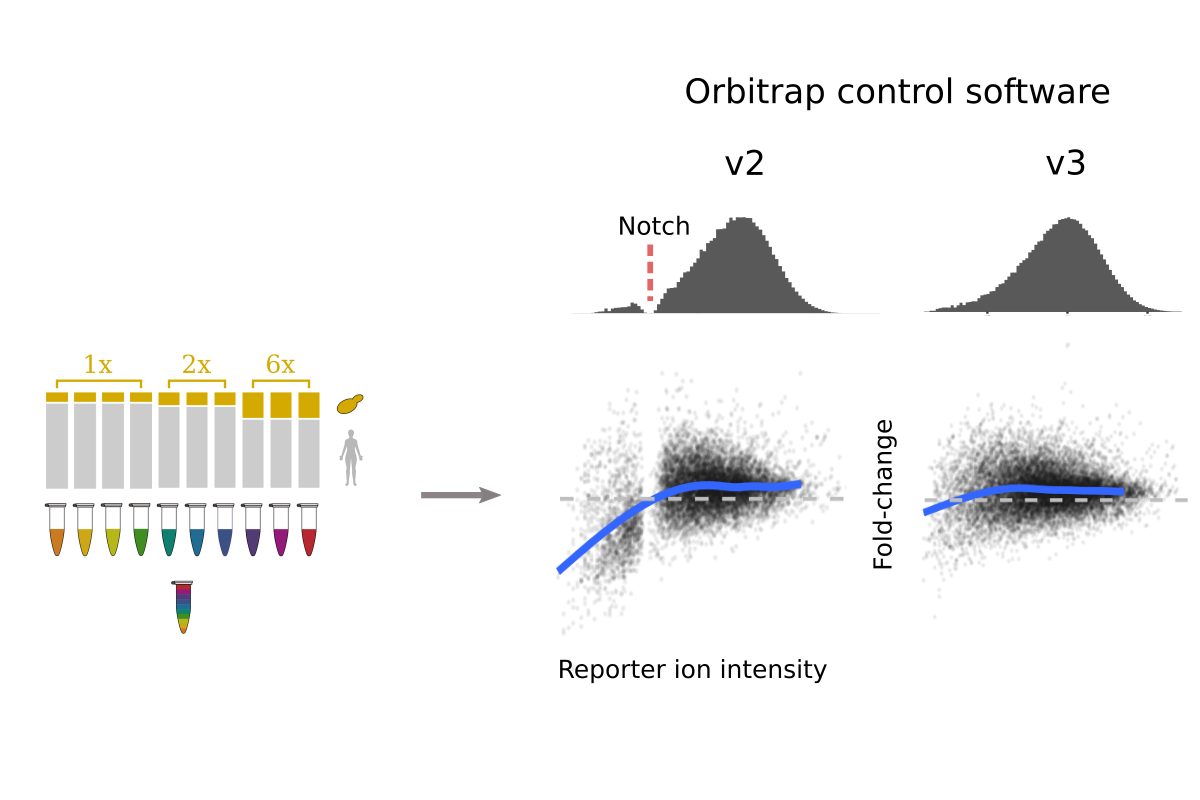

Los datos que utilizaremos están disponibles a través del Proteomics.analysis.datapaquete.



In [2]:
psm_data <- read.delim(
  system.file("extdata", 'benchmark_TMT', 'benchmark_TMT_PSMs.txt.gz',
              package = "Proteomics.analysis.data"))

<div style="font-family:'Times New Roman';">

El primer paso es eliminar las proteínas contaminantes. Estas se definieron utilizando la base de datos cRAP. A continuación, analizamos el fasta de cRAP para extraer los identificadores de las proteínas cRAP, tanto en formato "cRAP" como en Uniprot.

In [3]:
crap_fasta_inf <- system.file(
  "extdata", "cRAP_20190401.fasta.gz", 
  package = "Proteomics.analysis.data"
)

# Load the cRAP FASTA used for the PD search
crap.fasta <- Biostrings::fasta.index(crap_fasta_inf, seqtype = "AA")

# Extract the non cRAP UniProt accessions associated with each cRAP protein
crap.accessions <- crap.fasta %>% 
  pull(desc) %>% 
  stringr::str_extract_all(pattern = "(?<=\\|).*?(?=\\|)") %>% 
  unlist()

<div style="font-family:'Times New Roman';">

Podemos entonces proporcionar estos identificadores de proteína cRAP, lo parse_featuresque eliminará las características que puedan provenir de contaminantes, así como las que no tengan una proteína maestra única. Consulte ?parse_featurespara obtener más detalles, incluida la eliminación de "cRAP asociado".

In [4]:
psm_data_flt <- parse_features(
  psm_data, 
  crap_proteins = crap.accessions, 
  TMT = TRUE, 
  level = 'PSM'
)

Parsing features...

111919 features found from 11065 master proteins => Input

242 cRAP proteins supplied

1065 proteins identified as 'cRAP associated'

110452 features found from 11014 master proteins => cRAP features removed

109827 features found from 10983 master proteins => associated cRAP features removed

109779 features found from 10982 master proteins => features without a master protein removed

104305 features found from 9988 master proteins => features with non-unique master proteins removed



<div style="font-family:'Times New Roman';">

Ahora almacenamos los datos PSM filtrados en un MSnSet, el objeto de datos estándar para proteómica en R. Consulte vignette("msnset", package="camprotR")para obtener más detalles.

In [5]:
# Abundance columns for TMT PD-output start with Abundance 
abundance_cols <- colnames(psm_data_flt)[grepl('Abundance.', colnames(psm_data_flt))]

psm.e <- as.matrix(psm_data_flt[, abundance_cols])
psm.f <- psm_data_flt[, setdiff(colnames(psm_data_flt), abundance_cols)]

# update the column names to remove the 'Abundance.` prefix
colnames(psm.e) <- gsub('Abundance.', '', colnames(psm.e))

# we don't have 'phenotype' data to add so we just define the 
# 'expression' data and 'feature' data

psm.p <- data.frame(spike=rep(factor(c('x1', 'x2', 'x6')), c(4,3,3)), row.names=colnames(psm.e))
  
psm <- MSnbase::MSnSet(exprs = psm.e, fData = psm.f, pData=psm.p)

<div style="font-family:'Times New Roman';">

Distribuciones de intensidad de la gráfica

Warning message:
"Removed 10614 rows containing non-finite outside the scale range
(`stat_density()`)."


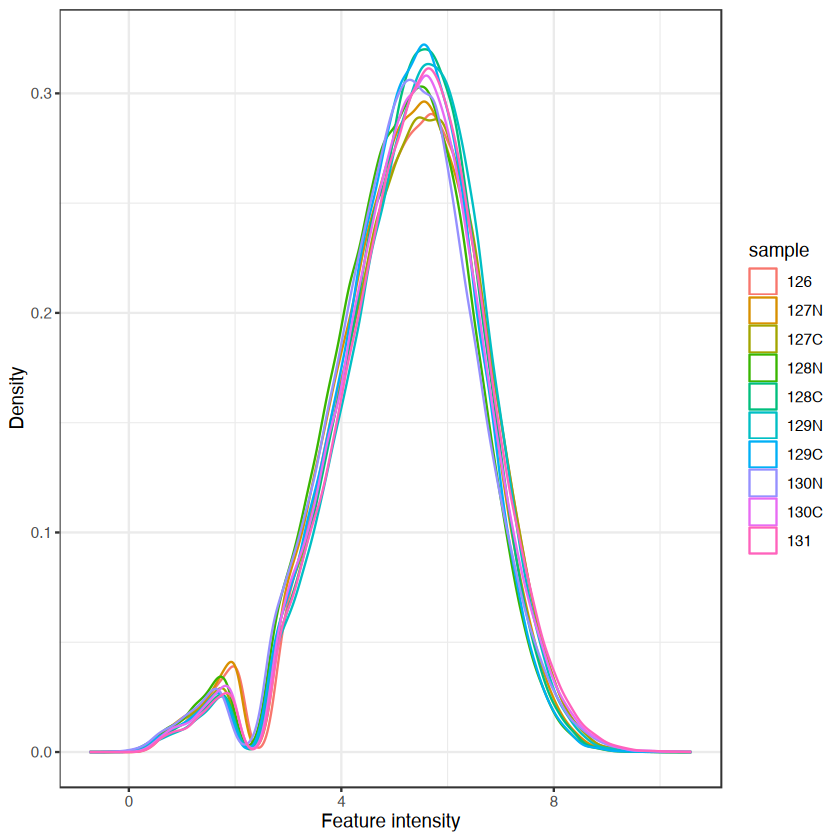

In [6]:
plot_quant(log(psm, base=2), method='density')


<div style="font-family:'Times New Roman';">

**Eliminación de PSM de baja calidad**

Queremos eliminar los PSM con baja relación señal-ruido (S:N), ya que los valores de cuantificación serán menos precisos y habrá más valores faltantes. Podemos inspeccionar la relación entre la S:N y los valores faltantes mediante la plot_missing_SNfunción.

Tenga en cuenta que cuando la relación señal:ruido > 5, hay muchos menos valores faltantes.

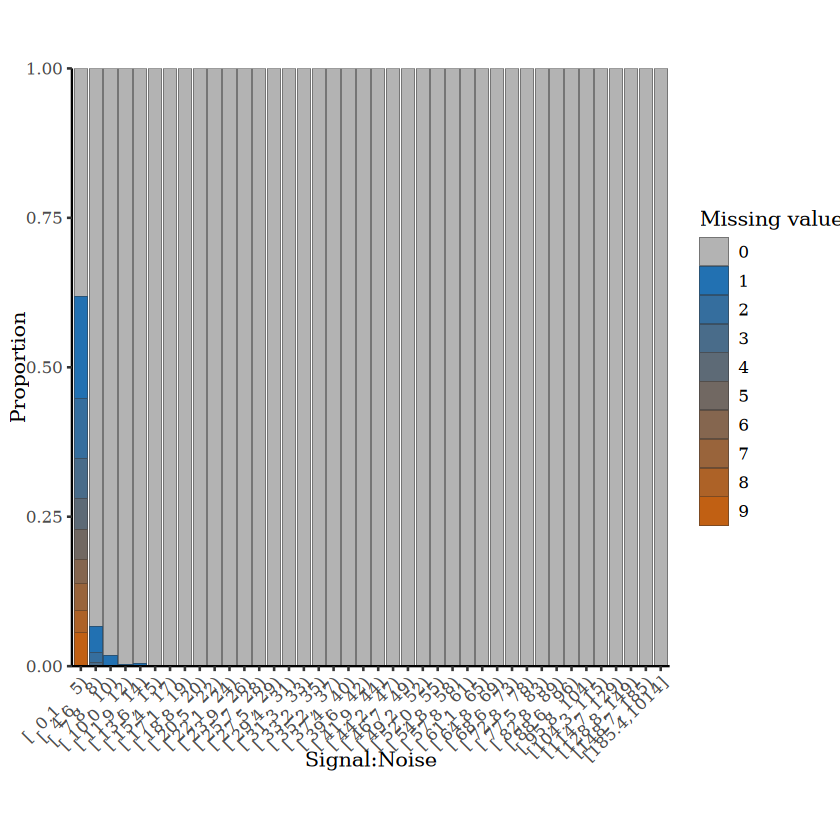

In [7]:
plot_missing_SN(psm, bins = 40)


<div style="font-family:'Times New Roman';">

Valores faltantes por PSM, en relación con la relación señal:ruido

También podemos analizar esta relación a nivel de etiqueta usando plot_missing_SN_per_sample. En este caso, no hay ninguna etiqueta que parezca tener una alta proporción de valores faltantes cuando la relación señal-ruido > 5. De existir, esto podría justificar una mayor investigación; por ejemplo, ¿fue inadecuada alguna de las preparaciones de la muestra, de modo que se etiquetaron menos péptidos?

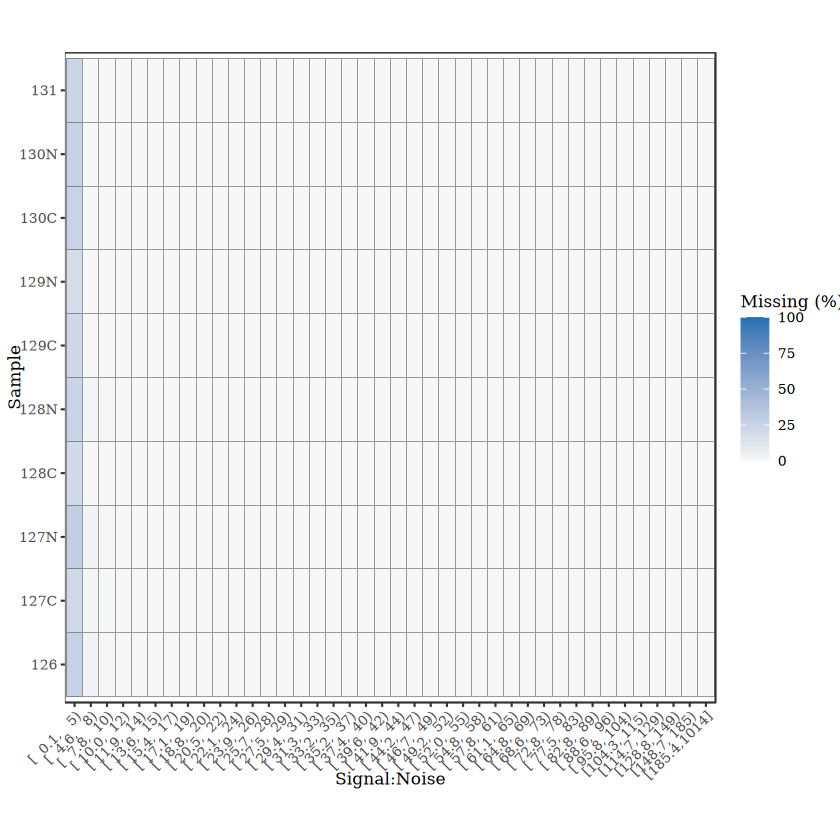

In [8]:
plot_missing_SN_per_sample(psm, bins = 40)


<div style="font-family:'Times New Roman';">

Valores faltantes por etiqueta, en relación con la relación señal:ruido

Con base en lo anterior, filtraremos los PSM para conservar únicamente aquellos con una relación señal/ruido > 5 usando filter_TMT_PSMs. Con la misma función, también eliminaremos los PSM con una interferencia/coaislamiento > 50%.

In [9]:
psm_filt_sn_int <- filter_TMT_PSMs(psm, inter_thresh = 50, sn_thresh = 5)


Filtering PSMs...

103907 features found from 9980 master proteins => No quant filtering

97768 features found from 9828 master proteins => Co-isolation filtering

95167 features found from 9780 master proteins => S:N ratio filtering



<div style="font-family:'Times New Roman';">

**Resumiendo la abundancia a nivel de proteínas**

Ahora que hemos inspeccionado la cuantificación a nivel de PSM y filtrado los PSM, podemos resumir los PSM en abundancias a nivel de proteína.

Discusión

¿Cómo crees que deberíamos resumir las abundancias a nivel de proteína a partir de la cuantificación a nivel de PSM?

¿Qué desventajas percibe usted en este enfoque?

Solución:

<div style="font-family:'Times New Roman';">

La síntesis de PSM a nivel proteico es mucho menos problemática para la cuantificación de TMT y muchos enfoques son válidos.

En la mayoría de los casos, hay pocos valores perdidos y la síntesis mediante métodos ingenuos como la media/mediana/suma es adecuada.

- La media/suma es sensible a los valores atípicos.
- La mediana es menos sensible a los valores atípicos, pero sensible a las intensidades de los PSM alrededor de la intensidad mediana.
 
Las intensidades a nivel de PSM pueden variar en varios órdenes de magnitud, siendo las más intensas probablemente las más precisas. El resumen de la media/suma se basa en gran medida en un subconjunto de PSM de alta intensidad. La suma tiene una sutil ventaja añadida, ya que también es mayor para las proteínas con más PSM. Esto puede ser útil en el análisis estadístico posterior, como veremos. La suma es un resumen predeterminado sensato para los datos TMT

En los casos (poco frecuentes) en los que hay muchos valores perdidos, el enfoque de resumen «robusto» de MSnbase::combineFeatures() puede ser adecuado (tras la transformación logarítmica), ya que gestiona los datos perdidos de forma adecuada.



<div style="font-family:'Times New Roman';">

Para el resumen de PSM a proteína, utilizaremos el resumen de "suma" ingenuo ( MSnbase::combineFeatures(method = 'sum')). Este enfoque no gestiona adecuadamente los valores faltantes, ya que devuelve NA si falta algún valor o, con valores na.rm=TRUEincluidos, reemplaza NA por cero cuando hay al menos un valor de cuantificación finito para una proteína. Por lo tanto, eliminaremos los pocos PSM con valores faltantes.



In [10]:
psm_filt_sn_int_missing <- psm_filt_sn_int %>% 
  MSnbase::filterNA()

<div style="font-family:'Times New Roman';">

Por lo general, se eliminan proteínas con un solo PSM, las llamadas "maravillas de un solo éxito", sobre la base de que es más probable que sean identificaciones positivas falsas y la cuantificación solo se extrae de una única observación.

In [11]:
psm_filt_sn_int_missing_n_features <- psm_filt_sn_int_missing %>%
  camprotR::restrict_features_per_protein(min_features=2, plot=FALSE)

<div style="font-family:'Times New Roman';">

A continuación realizamos el resumen.



In [12]:
protein <- psm_filt_sn_int_missing %>%
  MSnbase::combineFeatures(
    groupBy = fData(psm_filt_sn_int_missing)$Master.Protein.Accession,
    method = 'sum')

<div style="font-family:'Times New Roman';">

Finalmente, evaluamos la distribución de cuantificación y normalizamos las abundancias a nivel de proteína.



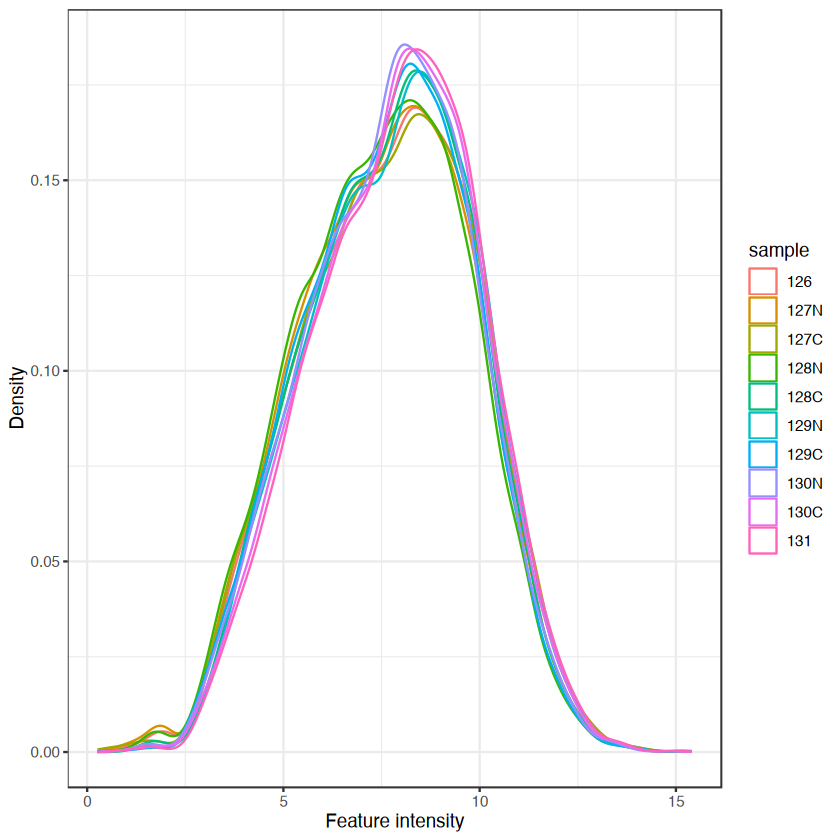

In [13]:
plot_quant(log(protein, base=2), method='density')


<div style="font-family:'Times New Roman';">

Para este conjunto de datos, observamos que las distribuciones de intensidad a nivel de proteína son muy similares. Este experimento de referencia se realizó generando 10 muestras a partir de mezclas definidas de 2 muestras de péptidos (humana y de levadura). Por lo tanto, esperamos distribuciones casi idénticas para todas las muestras del mismo grupo. En un experimento típico de TMT, es posible que se observen distribuciones más variables.

De cualquier modo, el siguiente paso debería ser normalizar las intensidades del nivel de proteína.

Aquí aplicaremos la normalización de la mediana de modo que las medianas de todas las columnas (muestras) coincidan con la mediana general. En MSnbase::normalise, esto se denomina diff.median. Dado que las intensidades tienen una distribución logarítmica gaussiana, las transformamos en logaritmos 2 antes de realizar la normalización.

La normalización de la mediana es una forma relativamente simple de normalización, ya que solo aplicamos una transformación con un único factor de corrección para cada muestra. Esto suele ser más apropiado cuando las muestras que se comparan son similares entre sí, como es el caso aquí.

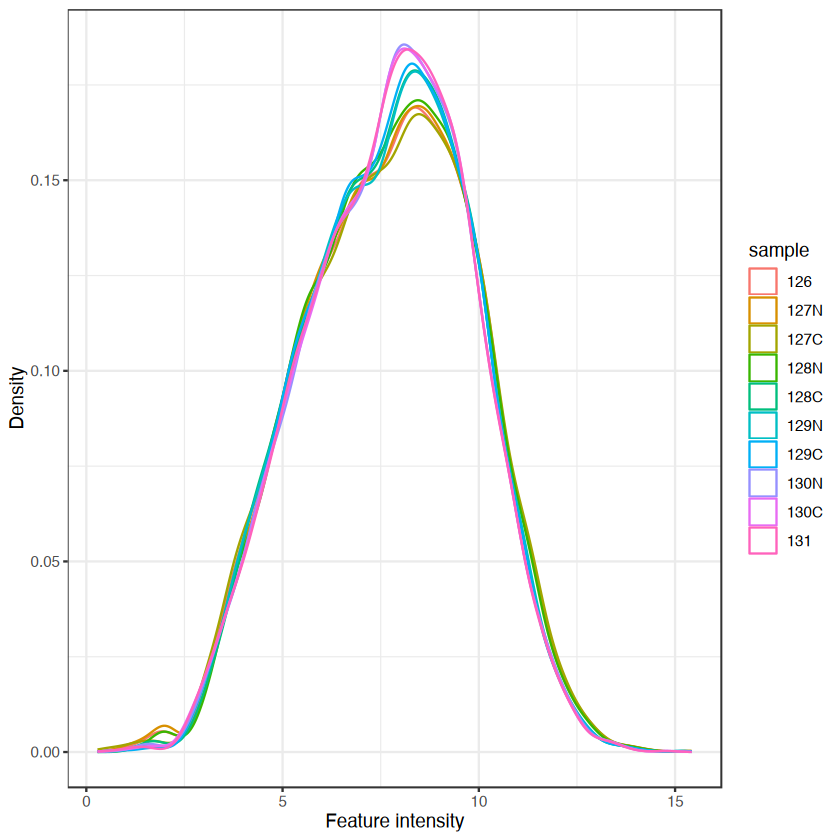

In [14]:
protein_norm <- MSnbase::normalise(log(protein, base=2), method='diff.median')

plot_quant(protein_norm, method='density')

<div style="font-family:'Times New Roman';">

Recuerde que podemos consultar la información de procesamiento de nuestro MSnSet si tenemos dudas sobre el procesamiento. Aquí, se indica que realizamos una transformación logarítmica 2 y luego aplicamos diff.medianla normalización.

In [15]:
processingData(protein_norm)


- - - Processing information - - -
Subset [104305,10][103907,10] Mon Feb  2 13:54:57 2026 
Subset [103907,10][97768,10] Mon Feb  2 13:54:58 2026 
Subset [97768,10][95167,10] Mon Feb  2 13:54:58 2026 
Subset [95167,10][94961,10] Mon Feb  2 14:00:48 2026 
Removed features with more than 0 NAs: Mon Feb  2 14:00:48 2026 
Dropped featureData's levels Mon Feb  2 14:00:48 2026 
Combined 94961 features into 9777 using sum: Mon Feb  2 14:01:49 2026 
Log transformed (base 2) Mon Feb  2 14:02:50 2026 
Normalised (diff.median): Mon Feb  2 14:02:51 2026 
 MSnbase version: 2.36.0 

<div style="font-family:'Times New Roman';">

Ahora hemos filtrado nuestra cuantificación a nivel de PSM, la hemos resumido a nivel de proteína y la hemos normalizado. Podemos usar este objeto para realizar visualizaciones posteriores, exploración de datos y análisis estadístico, etc.

Guardamos el objeto en el disco para poder volver a leerlo en la memoria cuando lo necesitemos.

In [16]:
saveRDS(psm_filt_sn_int_missing, '/Volumes/alex/BS_scripts_clase/proteomics-data-analysis-tutorial-master/psm_filt.rds')
saveRDS(protein_norm, '/Volumes/alex/BS_scripts_clase/proteomics-data-analysis-tutorial-master/tmt_protein.rds')

In [17]:
length(setdiff(fData(psm_filt_sn_int_missing)$Master.Protein.Accessions,
               fData(protein_norm)$Master.Protein.Accessions))

[1] 0